
# **0. 준비**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

In [ ]:
# 시각화에 사용할 팔레트
plt.style.available

sns.color_palette("pastel")
sns.set(palette='pastel')

In [ ]:
!git clone https://github.com/CheckNanbang/2025-weather-data-contest.git

Cloning into '2025-weather-data-contest'...
remote: Enumerating objects: 587, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 587 (delta 70), reused 76 (delta 39), pack-reused 462 (from 2)
Receiving objects: 100% (587/587), 103.44 MiB | 43.30 MiB/s, done.
Resolving deltas: 100% (271/271), done.


In [ ]:
%cd 2025-weather-data-contest/
! git pull

/content/2025-weather-data-contest
Already up to date.


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 21.3 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna

from preproccesor import WeatherDataPreprocessor
warnings.filterwarnings(action='ignore', category=UserWarning)

In [ ]:
!nvidia-smi

Thu Jun 26 08:17:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             42W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# **1. 데이터 전처리**

In [ ]:
df_train = pd.read_csv('/content/drive/MyDrive/weather_bigcontest/data/weather_data_imputed2.csv')
df_train.head(3)

,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,...,date,year,month,day,hour,quarter,day_of_week,season,is_weekend,hour_group
0,2021-01-01 01:00:00,A,-10.1,78.3,0.5,0.0,0.0,68.2,0.0,-8.2,...,2021-01-01,2021,1,1,1,1,4,Winter,Weekday,0
1,2021-01-01 02:00:00,A,-10.2,71.9,0.6,0.0,0.0,69.9,0.0,-8.6,...,2021-01-01,2021,1,1,2,1,4,Winter,Weekday,0
2,2021-01-01 03:00:00,A,-10.0,360.0,0.0,0.0,0.0,69.2,0.0,-8.8,...,2021-01-01,2021,1,1,3,1,4,Winter,Weekday,1


In [ ]:
preprocessor = WeatherDataPreprocessor()

cluster_results = preprocessor.preprocess_data(df_train, is_test=False)
cluster0_df = cluster_results.get('cluster0')

데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!


In [ ]:
cluster0_df.columns

Index(['tm', 'branch_id', 'ta', 'ws', 'rn_day', 'rn_hr1', 'hm', 'si', 'ta_chi',
       'heat_demand',
       ...
       'si_roll24', 'si_roll72', 'si_roll168', 'ta_chi_roll3', 'ta_chi_roll24',
       'ta_chi_roll72', 'ta_chi_roll168', 'dew_point', 'DI_interaction',
       'heat_demand_log'],
      dtype='object', length=238)

In [ ]:
cluster0_df

,tm,branch_id,ta,ws,rn_day,rn_hr1,hm,si,ta_chi,heat_demand,...,si_roll24,si_roll72,si_roll168,ta_chi_roll3,ta_chi_roll24,ta_chi_roll72,ta_chi_roll168,dew_point,DI_interaction,heat_demand_log
0,2021-01-01 01:00:00,E,-7.0,0.9,0.0,0.0,45.299909,0.0,-8.1,115.0,...,0.497917,0.463889,0.398155,-17.333333,-17.275000,-10.368056,-7.229167,-16.829145,0.0,4.753590
1,2021-01-01 02:00:00,E,-8.4,0.7,0.0,0.0,22.469247,0.0,-9.2,109.0,...,0.497917,0.463889,0.398155,-14.033333,-17.016667,-10.408333,-7.229167,-26.050843,0.0,4.700480
2,2021-01-01 03:00:00,E,-8.9,0.4,0.0,0.0,24.685172,0.0,-9.8,109.0,...,0.497917,0.463889,0.398155,-10.766667,-16.720833,-10.502778,-7.229167,-25.449711,0.0,4.700480
3,2021-01-01 04:00:00,E,-8.5,0.4,0.0,0.0,42.732703,0.0,-9.8,109.0,...,0.497917,0.463889,0.398155,-9.033333,-16.362500,-10.600000,-7.229167,-18.887002,0.0,4.700480
4,2021-01-01 05:00:00,E,-9.7,0.4,0.0,0.0,28.226857,0.0,-10.4,111.0,...,0.497917,0.463889,0.398155,-9.600000,-15.995833,-10.691667,-7.229167,-24.666368,0.0,4.718499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210213,2023-12-31 19:00:00,Q,0.6,0.0,7.0,0.0,95.400000,0.0,0.1,143.0,...,0.259167,0.157083,0.258512,2.800000,0.975000,-0.051389,-1.133929,-0.049658,0.0,4.969813
210214,2023-12-31 20:00:00,Q,-0.2,0.8,7.0,0.0,96.000000,0.0,-0.5,150.0,...,0.259167,0.157083,0.258512,1.700000,0.945833,-0.056944,-1.113690,-0.759597,0.0,5.017280
210215,2023-12-31 21:00:00,Q,-0.9,1.0,7.0,0.0,97.600000,0.0,-1.2,159.0,...,0.259167,0.157083,0.258512,0.600000,0.900000,-0.062500,-1.089286,-1.231367,0.0,5.075174
210216,2023-12-31 22:00:00,Q,-1.9,0.2,7.0,0.0,98.200000,0.0,-2.0,145.0,...,0.259167,0.157083,0.258512,-0.533333,0.825000,-0.073611,-1.067262,-2.145767,0.0,4.983607


# **2. 모델링**

##### (1) Base 모델

In [ ]:
# 데이터 준비
df = cluster0_df.copy()
df = df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 원핫 인코딩
object_cols = df.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df[object_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols))

# 나머지 수치형 변수
exclude_cols = object_cols + [target_col, "heat_demand", "heat_demand_log"]
numeric_df = df.drop(columns=exclude_cols)

# 최종 feature
X = pd.concat([numeric_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)


X['tm'] = pd.to_datetime(X['tm'])  # 만약 이미 datetime이면 이 줄 생략

# 1시간 단위로 시간 블록 생성 (연-월-일-시까지 포함됨)
X['time_block'] = X['tm'].dt.strftime('%Y-%m-%d %H:00:00')

X = X.drop('tm',axis=1)

# 고유한 시간 블록 추출 및 정렬
time_blocks = np.sort(X['time_block'].unique())

In [ ]:
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)
rmse_list = []

for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
    train_blocks = time_blocks[train_block_idx]
    val_blocks = time_blocks[val_block_idx]

    # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
    while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
        val_blocks = val_blocks[1:]

    train_idx = X['time_block'].isin(train_blocks)
    val_idx = X['time_block'].isin(val_blocks)

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train = X_train.drop('time_block',axis=1)
    X_val = X_val.drop('time_block',axis=1)

    model = XGBRegressor(random_state=42, n_jobs=-1, tree_method="gpu_hist", predictor="gpu_predictor")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    rmse_list.append(rmse)
    print(f"[Fold {fold}] RMSE: {rmse:.4f}")

print(f"평균 RMSE: {np.mean(rmse_list):.4f}")

[Fold 1] RMSE: 23.8434
[Fold 2] RMSE: 12.3438
[Fold 3] RMSE: 10.0676
평균 RMSE: 15.4183


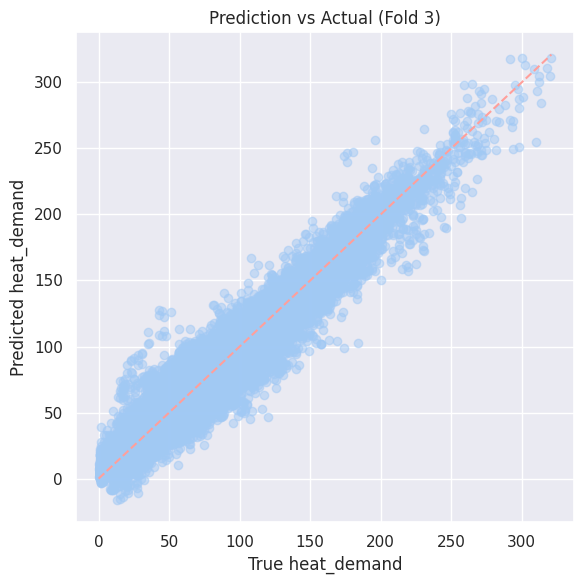

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True heat_demand")
plt.ylabel("Predicted heat_demand")
plt.title("Prediction vs Actual (Fold 3)")
plt.grid(True)
plt.tight_layout()
plt.show()

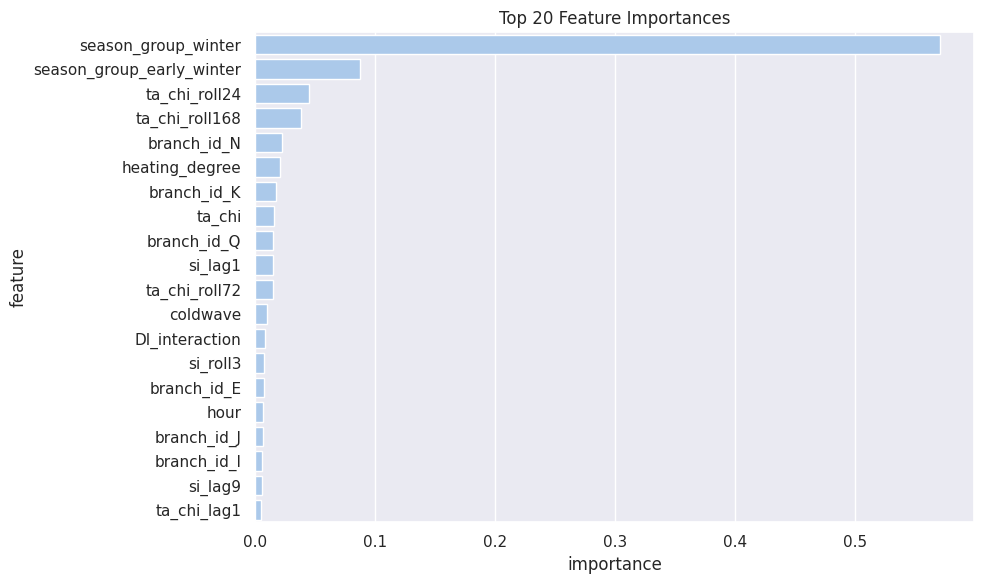

In [ ]:
X=X.drop('time_block',axis=1)

# feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))  # 상위 20개
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# 누적 기여도 99.5%까지 선택
importance_df['cumsum'] = importance_df['importance'].cumsum()
importance_df['cumsum_ratio'] = importance_df['cumsum'] / importance_df['importance'].sum()

# 95% 기여도 기준 상위 feature 추출
selected_features_995_nonlog = importance_df[importance_df['cumsum_ratio'] <= 0.995]['feature'].tolist()

print(f"선택된 feature 수: {len(selected_features_995_nonlog)}")

선택된 feature 수: 130


In [ ]:
selected_features_995_nonlog

['season_group_winter',
 'season_group_early_winter',
 'ta_chi_roll24',
 'ta_chi_roll168',
 'branch_id_N',
 'heating_degree',
 'branch_id_K',
 'ta_chi',
 'branch_id_Q',
 'si_lag1',
 'ta_chi_roll72',
 'coldwave',
 'DI_interaction',
 'si_roll3',
 'branch_id_E',
 'hour',
 'branch_id_J',
 'branch_id_I',
 'si_lag9',
 'ta_chi_lag1',
 'branch_id_F',
 'si_lag13',
 'si_lag10',
 'branch_id_O',
 'si_lag17',
 'si_lag15',
 'ws_roll168',
 'si_lag2',
 'day_flag',
 'ta_roll168',
 'weekofyear',
 'ta',
 'hour_sin',
 'hour_of_week',
 'ta_lag1',
 'ta_roll72',
 'hour_cos',
 'si_lag26',
 'season_group_summer',
 'si_lag12',
 'ta_diff_chi',
 'year',
 'si_lag18',
 'wd_cos_lag10',
 'si_lag3',
 'season_group_mid_season',
 'si_lag16',
 'month',
 'ta_roll3',
 'si_lag19',
 'ta_lag24',
 'ta_roll24',
 'ta_zone_low',
 'si_lag25',
 'ta_lag9',
 'ta_zone_mid',
 'si',
 'ta_chi_roll3',
 'si_lag23',
 'hm_lag19',
 'month_cos',
 'ta_lag22',
 'ta_lag12',
 'si_lag11',
 'ta_lag23',
 'month_sin',
 'ws',
 'si_lag14',
 'si_roll168'

In [ ]:
selected_features_995_nonlog =  ['season_group_winter','season_group_early_winter','ta_chi_roll24','ta_chi_roll168','branch_id_N','heating_degree','branch_id_K',
                                 'ta_chi','branch_id_Q','si_lag1','ta_chi_roll72','coldwave','DI_interaction','si_roll3','branch_id_E','hour','branch_id_J','branch_id_I',
                                 'si_lag9','ta_chi_lag1','branch_id_F','si_lag13','si_lag10','branch_id_O','si_lag17','si_lag15','ws_roll168','si_lag2','day_flag',
                                 'ta_roll168','weekofyear','ta','hour_sin','hour_of_week','ta_lag1','ta_roll72','hour_cos','si_lag26','season_group_summer','si_lag12','ta_diff_chi','year',
                                 'si_lag18','wd_cos_lag10','si_lag3','season_group_mid_season','si_lag16','month','ta_roll3','si_lag19','ta_lag24','ta_roll24','ta_zone_low','si_lag25',
                                 'ta_lag9','ta_zone_mid','si','ta_chi_roll3','si_lag23','hm_lag19','month_cos','ta_lag22','ta_lag12','si_lag11','ta_lag23','month_sin','ws','si_lag14','si_roll168',
                                 'cumulative_si','day','si_lag4','heatwave','ta_lag2','ta_lag25','ta_lag3','hm_roll168','si_lag5','ta_lag6','si_roll24','rn_hr1_roll168','ws_lag23','si_roll72',
                                 'ws_roll72','dew_point','monthday_sin','ws_roll24','hm_roll24','ta_lag10','ws_lag8','si_lag24','ta_lag4','rn_hr1_roll72','hm_roll72','weekhour_cos','ta_lag20',
                                 'monthday_cos','ta_lag7','ws_roll3','hm_lag7','wd_sin_lag1','ws_lag7','weekhour_sin','si_lag29','ws_lag22','hm_lag29','ta_chi_lag30','rn_hr1_roll24','ta_lag19',
                                 'rn_day','ws_lag5','ta_lag21','wd_cos_lag19','ws_lag24','wd_lag12','ta_zone_high','ws_lag18','hm_lag1','si_lag27','hm_lag17','rn_day_lag24','hm_lag2','ws_lag11',
                                 'wd_sin_lag12','ws_lag4','ws_lag21','hm_roll3','hm_lag8','hm_lag10','ta_lag8']

##### (2) 주요 변수 기반 모델 최적화

In [ ]:
# 데이터 준비
df = cluster0_df.copy()
df = df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 원핫 인코딩
object_cols = df.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df[object_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols))

# 나머지 수치형 변수
exclude_cols = object_cols + [target_col, "heat_demand", "heat_demand_log"]
numeric_df = df.drop(columns=exclude_cols)

# 최종 feature
X = pd.concat([numeric_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
X['tm'] = pd.to_datetime(X['tm'])  # 만약 이미 datetime이면 이 줄 생략

# 1시간 단위로 시간 블록 생성 (연-월-일-시까지 포함됨)
X['time_block'] = X['tm'].dt.strftime('%Y-%m-%d %H:00:00')

X = X.drop('tm',axis=1)

# 고유한 시간 블록 추출 및 정렬
time_blocks = np.sort(X['time_block'].unique())

In [ ]:
# 피쳐 선택
X_selected_995_nonlog = X[selected_features_995_nonlog + ['time_block']]

In [ ]:
n_splits = 3
tscv = TimeSeriesSplit(n_splits=n_splits)

# Optuna 목적 함수 정의
def objective(trial):
    fold_preds = {}
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1000),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 0.75),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 0.01, log=True),
        "random_state": 42,
        "n_jobs": -1
    }

    rmse_list = []

    for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
        train_blocks = time_blocks[train_block_idx]
        val_blocks = time_blocks[val_block_idx]

        # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
        while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
            val_blocks = val_blocks[1:]

        train_idx = X_selected_995_nonlog['time_block'].isin(train_blocks) #이전 코드에서 생성된 것 참조
        val_idx = X_selected_995_nonlog['time_block'].isin(val_blocks)

        X_train, X_val = X_selected_995_nonlog[train_idx], X_selected_995_nonlog[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        X_train = X_train.drop('time_block',axis=1)
        X_val = X_val.drop('time_block',axis=1)

        sample_weight = np.log1p(y_train)
        model = XGBRegressor(
            **params,
            tree_method="gpu_hist",
            predictor="gpu_predictor"
        )
        model.fit(X_train, y_train, sample_weight =sample_weight)

        y_pred = model.predict(X_val)

        # fold별 결과 저장
        fold_preds[f"Fold{fold+1}"] = {
            "y_true": y_val,
            "y_pred": y_pred
        }

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_list.append(rmse)

    return np.mean(rmse_list)

# Optuna 튜닝 실행
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=1000)

# 최적 하이퍼파라미터 출력
print("Best trial:")
print(study.best_trial)

[I 2025-06-26 08:23:46,588] A new study created in memory with name: no-name-99a71254-a9f1-44bd-8c52-7b760cc4639f
[I 2025-06-26 08:23:56,989] Trial 0 finished with value: 12.923162059343063 and parameters: {'n_estimators': 391, 'max_depth': 8, 'learning_rate': 0.05160341666066254, 'subsample': 0.5244419480563159, 'colsample_bytree': 0.808977334403645, 'reg_alpha': 0.0007748246076376173, 'reg_lambda': 6.72611517586287e-07}. Best is trial 0 with value: 12.923162059343063.
[I 2025-06-26 08:24:14,179] Trial 1 finished with value: 12.796623581234028 and parameters: {'n_estimators': 772, 'max_depth': 8, 'learning_rate': 0.05080183166102052, 'subsample': 0.7359279553278657, 'colsample_bytree': 0.7700448575237218, 'reg_alpha': 0.0004566965537141016, 'reg_lambda': 0.0019480413666998124}. Best is trial 1 with value: 12.796623581234028.
[I 2025-06-26 08:24:22,481] Trial 2 finished with value: 12.668778859657143 and parameters: {'n_estimators': 312, 'max_depth': 8, 'learning_rate': 0.0618954734594

Best trial:
FrozenTrial(number=230, state=1, values=[12.135960179725215], datetime_start=datetime.datetime(2025, 6, 26, 9, 4, 19, 647464), datetime_complete=datetime.datetime(2025, 6, 26, 9, 4, 30, 345510), params={'n_estimators': 930, 'max_depth': 6, 'learning_rate': 0.04610582490653898, 'subsample': 0.5530677444010951, 'colsample_bytree': 0.9372943847364046, 'reg_alpha': 1.8929668699316567e-08, 'reg_lambda': 1.9018409383453436e-08}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=300, step=1), 'max_depth': IntDistribution(high=8, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=0.75, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.7, step=None), 'reg_alpha': FloatDistribution(high=10.0, log=True, low=1e-08, step=None), 'reg_lambda': FloatDistribution(high=0.01, log=

In [ ]:
# 최적 하이퍼파라미터 출력
print("Best trial:")
print(study.best_trial)

Best trial:
FrozenTrial(number=230, state=1, values=[12.135960179725215], datetime_start=datetime.datetime(2025, 6, 26, 9, 4, 19, 647464), datetime_complete=datetime.datetime(2025, 6, 26, 9, 4, 30, 345510), params={'n_estimators': 930, 'max_depth': 6, 'learning_rate': 0.04610582490653898, 'subsample': 0.5530677444010951, 'colsample_bytree': 0.9372943847364046, 'reg_alpha': 1.8929668699316567e-08, 'reg_lambda': 1.9018409383453436e-08}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=300, step=1), 'max_depth': IntDistribution(high=8, log=False, low=4, step=1), 'learning_rate': FloatDistribution(high=0.1, log=True, low=0.001, step=None), 'subsample': FloatDistribution(high=0.75, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.7, step=None), 'reg_alpha': FloatDistribution(high=10.0, log=True, low=1e-08, step=None), 'reg_lambda': FloatDistribution(high=0.01, log=

In [ ]:
study.best_trial.params

{'n_estimators': 930,
 'max_depth': 6,
 'learning_rate': 0.04610582490653898,
 'subsample': 0.5530677444010951,
 'colsample_bytree': 0.9372943847364046,
 'reg_alpha': 1.8929668699316567e-08,
 'reg_lambda': 1.9018409383453436e-08}

In [ ]:
best_params = study.best_trial.params
best_params.update({
    "tree_method": "gpu_hist",
    "predictor": "gpu_predictor",
    "random_state": 42,
    "n_jobs": -1
})

results_weighted = {}
rmse_list, mae_list, r2_list = [], [], []

tscv = TimeSeriesSplit(n_splits=3)
for fold, (train_block_idx, val_block_idx) in enumerate(tscv.split(time_blocks), start=1):
    train_blocks = time_blocks[train_block_idx]
    val_blocks = time_blocks[val_block_idx]

    # 겹치는 시간 블록이 있다면 validation 앞부분에서 제거
    while len(val_blocks) > 0 and val_blocks[0] in train_blocks:
        val_blocks = val_blocks[1:]

    train_idx = X_selected_995_nonlog['time_block'].isin(train_blocks) #이전 코드에서 생성된 것 참조
    val_idx = X_selected_995_nonlog['time_block'].isin(val_blocks)

    X_train, X_val = X_selected_995_nonlog[train_idx], X_selected_995_nonlog[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    X_train = X_train.drop('time_block',axis=1)
    X_val = X_val.drop('time_block',axis=1)

    sample_weight = np.log1p(y_train)

    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train, sample_weight=sample_weight)

    y_pred = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)

    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

results_weighted["Average"] = {
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "R2": np.mean(r2_list)
}

# 3. 결과 출력
from pprint import pprint
pprint(results_weighted['Average'])

{'MAE': np.float64(8.929289308330684),
 'R2': np.float64(0.9430045597755314),
 'RMSE': np.float64(12.135960179725215)}


In [ ]:
# 4. 최종 모델 학습
X_selected_995_nonlog = X[selected_features_995_nonlog + ['time_block']]
X_selected_995_nonlog = X_selected_995_nonlog.drop('time_block',axis=1)

best_params = study.best_trial.params
best_params.update({
    "tree_method": "gpu_hist",
    "predictor": "gpu_predictor",
    "random_state": 42,
    "n_jobs": -1
})

sample_weight = np.log1p(y)  # 선형 증가 가중치
final_model = XGBRegressor(**best_params)
final_model.fit(X_selected_995_nonlog, y, sample_weight=sample_weight)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9372943847364046, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04610582490653898, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=930, n_jobs=-1,
             num_parallel_tree=None, predictor='gpu_predictor', ...)

In [ ]:
import joblib
joblib.dump(final_model, '/content/drive/MyDrive/weather_bigcontest/model/xgb_model_0625_ver1.pkl')

['/content/drive/MyDrive/weather_bigcontest/model/xgb_model_0625_ver1.pkl']

# **3. Shap**

In [ ]:
import shap

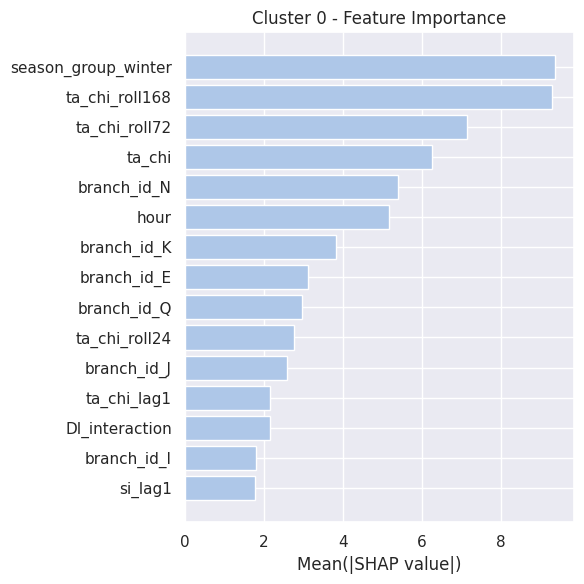

In [ ]:
# 1. SHAP Explainer 생성 및 SHAP 값 계산
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_selected_995_nonlog)

# 2. SHAP 값 절댓값의 평균 구하기
mean_shap = np.abs(shap_values).mean(axis=0)
feature_names = X_selected_995_nonlog.columns

# 3. 상위 15개 feature
shap_df = pd.DataFrame({
    'Feature': feature_names,
    'MeanAbsSHAP': mean_shap
}).sort_values(by='MeanAbsSHAP', ascending=False).head(15)

# 4. bar plot 그리기
plt.figure(figsize=(6, 6))
bars = plt.barh(shap_df['Feature'][::-1], shap_df['MeanAbsSHAP'][::-1], color='#aec7e8')
plt.xlabel('Mean(|SHAP value|)')
plt.title('Cluster 0 - Feature Importance')
plt.tight_layout()
plt.show()

# **4. Test**

* test data 불러오기

In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/weather_bigcontest/data/non_null_test_data_dh.csv')
df_test.head(3)

,tm,branch_id,ta,wd,ws,rn_day,rn_hr1,hm,si,ta_chi,...,date,year,month,day,hour,quarter,day_of_week,season,is_weekend,hour_group
0,2024-01-01 00:00:00,A,0.5,171.3,0.8,2.5,0.0,97.1,0.0,0.3,...,2024-01-01,2024,1,1,0,1,0,Winter,Weekday,0
1,2024-01-01 01:00:00,A,0.4,93.7,1.0,0.0,0.0,96.8,0.0,0.1,...,2024-01-01,2024,1,1,1,1,0,Winter,Weekday,0
2,2024-01-01 02:00:00,A,-0.1,133.0,0.8,0.0,0.0,97.0,0.0,0.0,...,2024-01-01,2024,1,1,2,1,0,Winter,Weekday,0


In [ ]:
preprocessor = WeatherDataPreprocessor()

cluster_results = preprocessor.preprocess_data(df_test, is_test=False)
cluster0_df_test = cluster_results.get('cluster0')

데이터 전처리 시작...
cluster2_summer 전처리 중...
cluster2_non_summer 전처리 중...
cluster1 전처리 중...
cluster0 전처리 중...
cluster3 전처리 중...
클러스터별 데이터 전처리 완료!


In [ ]:
cluster0_df_test

,tm,branch_id,ta,ws,rn_day,rn_hr1,hm,si,ta_chi,heat_demand,...,si_roll24,si_roll72,si_roll168,ta_chi_roll3,ta_chi_roll24,ta_chi_roll72,ta_chi_roll168,dew_point,DI_interaction,heat_demand_log
0,2024-01-01 00:00:00,E,-1.8,0.1,2.823568,0.290876,94.9,0.0,-1.8,0,...,0.469583,0.405972,0.301131,-7.766667,-5.950000,-0.737500,0.123214,-2.507485,0.0,0.0
1,2024-01-01 01:00:00,E,-2.0,1.4,0.000000,0.000000,95.3,0.0,-2.0,0,...,0.469583,0.405972,0.301131,-6.300000,-5.970833,-0.790278,0.123214,-2.649693,0.0,0.0
2,2024-01-01 02:00:00,E,-1.9,0.4,0.000000,0.000000,95.2,0.0,-1.8,0,...,0.469583,0.405972,0.301131,-3.800000,-5.870833,-0.851389,0.123214,-2.564385,0.0,0.0
3,2024-01-01 03:00:00,E,-1.8,0.5,0.000000,0.000000,95.4,0.0,-1.8,0,...,0.469583,0.405972,0.301131,-1.866667,-5.837500,-0.901389,0.123214,-2.436655,0.0,0.0
4,2024-01-01 04:00:00,E,-1.7,0.3,0.000000,0.000000,95.5,0.0,-1.4,0,...,0.469583,0.405972,0.301131,-1.866667,-5.783333,-0.950000,0.123214,-2.323056,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70275,2024-12-31 20:00:00,Q,-2.3,0.9,0.000000,0.000000,57.8,0.0,-2.9,0,...,0.438750,0.376111,0.387440,-1.166667,-1.725000,-0.670833,-2.452976,-9.474208,0.0,0.0
70276,2024-12-31 21:00:00,Q,-3.4,1.1,0.000000,0.000000,62.6,0.0,-4.3,0,...,0.438750,0.376111,0.387440,-1.933333,-1.908333,-0.650000,-2.445238,-9.500794,0.0,0.0
70277,2024-12-31 22:00:00,Q,-4.0,0.2,0.000000,0.000000,65.2,0.0,-5.0,0,...,0.438750,0.376111,0.387440,-2.700000,-2.116667,-0.627778,-2.446429,-9.555178,0.0,0.0
70278,2024-12-31 23:00:00,Q,-4.7,0.2,0.000000,0.000000,71.6,0.0,-5.5,0,...,0.438750,0.376111,0.387440,-4.066667,-2.300000,-0.601389,-2.451786,-9.035873,0.0,0.0


* 예측

In [ ]:
# 데이터 준비
df = cluster0_df.copy()
df = df.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 원핫 인코딩
object_cols = df.select_dtypes(include="object").columns.tolist()
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_array = encoder.fit_transform(df[object_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(object_cols))

# 나머지 수치형 변수
exclude_cols = object_cols + [target_col, "heat_demand", "heat_demand_log"]
numeric_df = df.drop(columns=exclude_cols)

# 최종 feature
X = pd.concat([numeric_df.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
X['tm'] = pd.to_datetime(X['tm'])  # 만약 이미 datetime이면 이 줄 생략

# 1시간 단위로 시간 블록 생성 (연-월-일-시까지 포함됨)
X['time_block'] = X['tm'].dt.strftime('%Y-%m-%d %H:00:00')

X = X.drop('tm',axis=1)

# 고유한 시간 블록 추출 및 정렬
time_blocks = np.sort(X['time_block'].unique())

In [ ]:
# 4. 최종 모델 학습
X_selected_995_nonlog = X[selected_features_995_nonlog + ['time_block']]
X_selected_995_nonlog = X_selected_995_nonlog.drop('time_block',axis=1)

# 고정 Best Params
best_params = {
    'n_estimators': 930,
    'max_depth': 6,
    'learning_rate': 0.04610582490653898,
    'subsample': 0.5530677444010951,
    'colsample_bytree': 0.9372943847364046,
    'reg_alpha': 1.8929668699316567e-08,
    'reg_lambda': 1.9018409383453436e-08,
    'tree_method': 'gpu_hist',
    'predictor': 'gpu_predictor',
    'random_state': 42,
    'n_jobs': -1
}

sample_weight = np.log1p(y)  # 로그 가중치
final_model = XGBRegressor(**best_params)
final_model.fit(X_selected_995_nonlog, y, sample_weight=sample_weight)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9372943847364046, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.04610582490653898, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=930, n_jobs=-1,
             num_parallel_tree=None, predictor='gpu_predictor', ...)

In [ ]:
# test 데이터 복사 및 전처리
df_test = cluster0_df_test.copy()
df_test = df_test.sort_values(["tm", "branch_id"]).reset_index(drop=True)

# 타겟 지정
target_col = "heat_demand"
y = df[target_col]

# object 컬럼 인코딩
encoded_array_test = encoder.transform(df_test[object_cols])  # 학습된 encoder 사용
encoded_df_test = pd.DataFrame(encoded_array_test, columns=encoder.get_feature_names_out(object_cols))

# 수치형 + 인코딩 합치기
exclude_cols = object_cols + ['tm', target_col, "heat_demand", "heat_demand_log"]
numeric_df_test = df_test.drop(columns=exclude_cols)
X_test = pd.concat([numeric_df_test.reset_index(drop=True), encoded_df_test.reset_index(drop=True)], axis=1)

# 선택된 변수로 축소
X_test_selected = X_test[selected_features_995_nonlog]

# 예측
y_pred= final_model.predict(X_test_selected)

# 결과를 test 데이터에 붙이기 (선택)
df_test["heat_demand_pred"] = y_pred

# 출력
df_test[["tm", "branch_id", "heat_demand_pred"]].head()

,tm,branch_id,heat_demand_pred
0,2024-01-01,E,99.481087
1,2024-01-01,F,135.425659
2,2024-01-01,I,157.982376
3,2024-01-01,J,169.192383
4,2024-01-01,K,91.468246


In [ ]:
df_test[["tm", "branch_id", "heat_demand_pred"]].to_csv(
    "/content/drive/MyDrive/weather_bigcontest/result/df_test_cluster0_0626_ver1.csv",
    index=False
)